# ROME: Causal Tracing and Rank-One Editing

[ROME](https://arxiv.org/abs/2202.05262) first locates factual recall with causal tracing, then changes one fact through a rank-one weight update. Here TDHook reproduces both parts on GPT-2 XL: three causal traces and ten CounterFact edits.

In [1]:
from __future__ import annotations
import contextlib
import importlib.util
import io
import json
import os
from pathlib import Path
import sys
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from transformers import AutoModelForCausalLM, AutoTokenizer
from tensordict import TensorDict, NonTensorData
from tensordict.nn import TensorDictModule
from tdhook.workflow import Workflow

notebook_relative_dir = Path("docs/source/notebooks/tutorials")
notebook_dir = next(
    (
        root / notebook_relative_dir
        for root in (Path.cwd(), *Path.cwd().parents)
        if (root / notebook_relative_dir).is_dir()
    ),
    Path.cwd() if Path.cwd().name == "tutorials" else None,
)

In [2]:
if notebook_dir is None:
    raise FileNotFoundError(f"Could not locate {notebook_relative_dir}")
sys.path.insert(0, str(notebook_dir))
from rome_reproduction import (  # noqa: E402
    CausalTraceConfig,
    causal_trace_grid,
    causal_trace_window_grid,
    parity_report,
    summarize_counterfact,
    temporary_rank_one_edit,
)

KNOWN_URL = "https://rome.baulab.info/data/dsets/known_1000.json"
COUNTERFACT_URL = "https://rome.baulab.info/data/dsets/counterfact.json"
data_dir = notebook_dir / "rome-data"
data_dir.mkdir(exist_ok=True)

In [3]:
def download(url, name):
    path = data_dir / name
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return json.loads(path.read_text())

In [4]:
knowns = download(KNOWN_URL, "known_1000.json")
counterfact = download(COUNTERFACT_URL, "counterfact.json")

## Load ROME and GPT-2 XL

The official ROME checkout must be available on `PYTHONPATH`. Loading the model requires CUDA and about 7 GB of downloads.

In [5]:
rome_spec = importlib.util.find_spec("rome")
if rome_spec is None or rome_spec.origin is None:
    raise ImportError("Put the official ROME checkout on PYTHONPATH")
official_root = Path(rome_spec.origin).resolve().parents[1]
cwd = Path.cwd()
try:
    os.chdir(official_root)
    from experiments.causal_trace import (
        collect_embedding_std,
        find_token_range,
        make_inputs,
        predict_from_input,
        trace_important_states,
        trace_important_window,
    )
    from experiments.py.eval_utils_counterfact import compute_rewrite_quality_counterfact
    from rome import ROMEHyperParams
    from rome.rome_main import execute_rome
finally:
    os.chdir(cwd)
if not torch.cuda.is_available():
    raise RuntimeError("GPT-2 XL requires CUDA.")
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2-xl")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2-xl").eval().cuda()

In [6]:
model.config._name_or_path = "gpt2-xl"
for parameter in model.parameters():
    parameter.requires_grad_(False)
display(Markdown(f"**Ready:** GPT-2 XL on `{torch.cuda.get_device_name()}`"))

**Ready:** GPT-2 XL on `NVIDIA A100 80GB PCIe`

## Locate factual recall

For each prompt, TDHook constructs a two-step `Workflow`: a configured intervention corrupts the subject tokens and restores one hidden state, then a TensorDict operator computes answer recovery. The outer Python sweep invokes that workflow across token-layer locations; bright cells show where restoration recovers the original answer probability.

In [7]:
noise = 3.0 * collect_embedding_std(
    type("ModelAndTokenizer", (), {"model": model, "tokenizer": tokenizer})(),
    [item["subject"] for item in knowns],
)
trace_config = CausalTraceConfig(samples=10, noise_seed=1, noise_level=noise)
layer_paths = [f"transformer.h.{layer}" for layer in range(model.config.n_layer)]
trace_rows = []
first_heatmap = None

Define the comparison for one factual prompt, then run it on the three selected cases.

In [8]:
def trace_case(model, tokenizer, case, layer_paths, trace_config):
    """Compare residual and MLP restoration against the released implementation."""
    inputs = make_inputs(tokenizer, [case["prompt"]] * 11)
    answer_tokens, probabilities = predict_from_input(model, inputs)
    answer_token = int(answer_tokens[0])
    subject_range = find_token_range(tokenizer, inputs["input_ids"][0], case["subject"])

    official = trace_important_states(
        model, model.config.n_layer, inputs, subject_range, answer_token, noise=trace_config.noise_level
    )
    official_mlp = trace_important_window(
        model,
        model.config.n_layer,
        inputs,
        subject_range,
        answer_token,
        kind="mlp",
        window=10,
        noise=trace_config.noise_level,
    )
    tdhook = causal_trace_grid(model, inputs, answer_token, subject_range, layer_paths, config=trace_config)
    tdhook_mlp = causal_trace_window_grid(
        model, inputs, answer_token, subject_range, layer_paths, component="mlp", window=10, config=trace_config
    )
    residual_difference = parity_report(tdhook, official, atol=1e-5, rtol=1e-5)["max_abs_difference"]
    mlp_difference = parity_report(tdhook_mlp, official_mlp, atol=1e-5, rtol=1e-5)["max_abs_difference"]
    row = {
        "Prompt": case["prompt"],
        "Answer": tokenizer.decode([answer_token]).strip(),
        "Answer probability": float(probabilities[0]),
        "Max trace difference": max(residual_difference, mlp_difference),
    }
    return row, tdhook_mlp.detach().cpu(), inputs["input_ids"][0]

In [9]:
for case_id in (0, 1, 2):
    row, heatmap, input_ids = trace_case(model, tokenizer, knowns[case_id], layer_paths, trace_config)
    trace_rows.append(row)
    if first_heatmap is None:
        first_heatmap, first_inputs = heatmap, input_ids
trace_table = pd.DataFrame(trace_rows)
display(
    trace_table.style.format({"Answer probability": "{:.1%}", "Max trace difference": "{:.1e}"}).hide(axis="index")
)

Prompt,Answer,Answer probability,Max trace difference
Vinson Massif is located in the continent of,Antarctica,9.5%,1.5e-08
Beats Music is owned by,Apple,68.4%,1.2e-07
Audible.com is owned by,Amazon,25.6%,3.0e-08


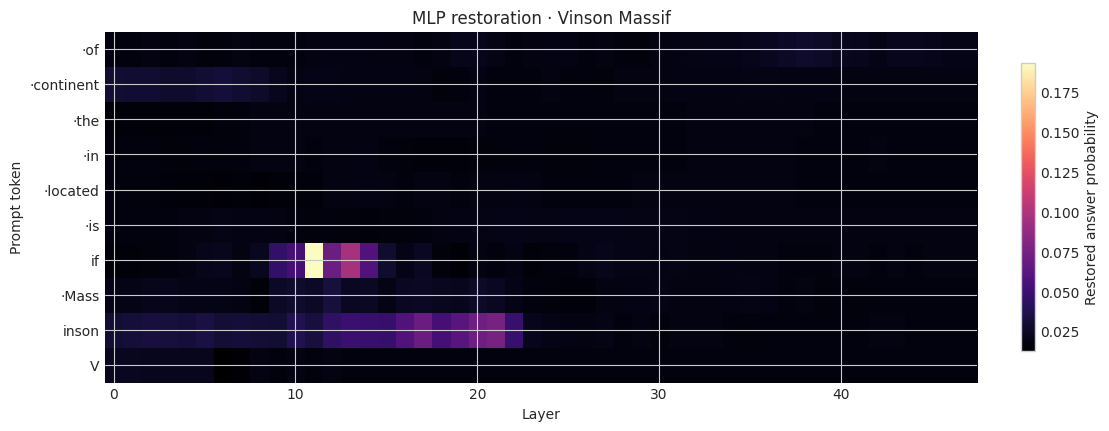

In [10]:
token_labels = [tokenizer.decode([int(token)]).replace(" ", "·") for token in first_inputs]
with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axis = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
    image = axis.imshow(first_heatmap, aspect="auto", origin="lower", cmap="magma")
    axis.set(
        title=f"MLP restoration · {knowns[0]['subject']}",
        xlabel="Layer",
        ylabel="Prompt token",
    )
    axis.set_yticks(range(len(token_labels)), token_labels)
    axis.spines[:].set_visible(False)
    figure.colorbar(image, ax=axis, label="Restored answer probability", shrink=0.82)
    plt.show()

## Rewrite ten facts

For each CounterFact example, ROME derives a rank-one update and TDHook applies it temporarily while the official evaluator measures the edited model.

In [11]:
hparams = ROMEHyperParams.from_json(official_root / "hparams/ROME/gpt2-xl.json")

The edit workflow declares the dependency from a CounterFact record to the ROME update and from that update to temporary application and evaluation. Official ROME supplies the update and evaluator; TDHook supplies artifact composition and restoration.

In [12]:
def derive_rank_one_edit(record):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        deltas = execute_rome(model, tokenizer, record["requested_rewrite"], hparams)
    return NonTensorData(deltas)

In [13]:
def evaluate_rank_one_edit(record, deltas):
    weight_name, (left, right) = next(iter(deltas.items()))
    module_path, parameter_name = weight_name.rsplit(".", 1)
    with temporary_rank_one_edit(model, module_path, parameter_name, left, right) as edited_model:
        post = compute_rewrite_quality_counterfact(edited_model, tokenizer, record, None, None)
    return NonTensorData({"case_id": record["case_id"], "post": post})

In [14]:
edit_workflow = Workflow(
    TensorDictModule(derive_rank_one_edit, in_keys=["record"], out_keys=[("edit", "deltas")]),
    TensorDictModule(
        evaluate_rank_one_edit, in_keys=["record", ("edit", "deltas")], out_keys=[("metrics", "edited_case")]
    ),
)

In [15]:
edited_cases = []
for record in counterfact[:10]:
    data = TensorDict({"record": NonTensorData(record)}, batch_size=[])
    result = edit_workflow(model, data)
    edited_cases.append(result["metrics", "edited_case"])
counterfact_summary = summarize_counterfact(edited_cases)

  0%|          | 0/1000 [00:00<?, ?it/s]

## What changed?

The ten-example rerun is small, so we place it next to the full-benchmark values from Table 4 instead of turning it into a pass/fail check.

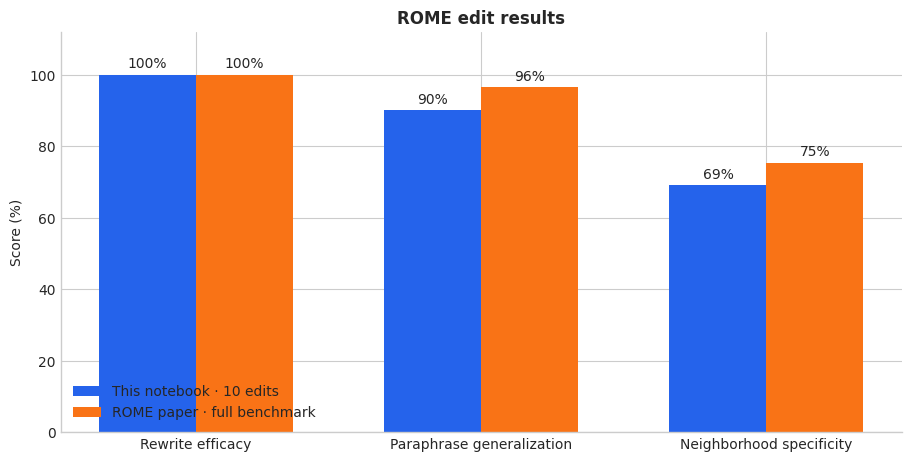

All three TDHook causal traces agree with the released implementation to numerical precision. On the ten edits, efficacy is **100%**, paraphrase generalization **90%**, and neighborhood specificity **69%**.

In [16]:
labels = ["Rewrite efficacy", "Paraphrase generalization", "Neighborhood specificity"]
keys = ["rewrite_efficacy", "paraphrase_generalization", "neighborhood_specificity"]
observed = [100 * counterfact_summary["metrics"][key] for key in keys]
paper = [100.0, 96.4, 75.4]
x = np.arange(len(labels))
with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    width = 0.34
    left = axis.bar(x - width / 2, observed, width, label="This notebook · 10 edits", color="#2563eb")
    right = axis.bar(x + width / 2, paper, width, label="ROME paper · full benchmark", color="#f97316")
    axis.bar_label(left, fmt="%.0f%%", padding=3)
    axis.bar_label(right, fmt="%.0f%%", padding=3)
    axis.set_ylim(0, 112)
    axis.set_ylabel("Score (%)")
    axis.set_xticks(x, labels)
    axis.set_title("ROME edit results", fontweight="bold")
    axis.legend(frameon=False, loc="lower left")
    axis.spines[["top", "right"]].set_visible(False)
    plt.show()
display(
    Markdown(
        "All three TDHook causal traces agree with the released implementation to numerical precision. "
        "On the ten edits, efficacy is **100%**, paraphrase generalization **90%**, and neighborhood specificity **69%**."
    )
)